# Introduzione
In questo documento si analizza un Dataset di vendite sintetico a scopo didattico, simulando un tipico workflow da Data Scientist semplificato. 
Il progetto è strutturato come segue:

1. **Caricamento ed Esplorazioni Dati**:
    - generazioni Dataset sintetico con valori mancanti,
    - esplorazione del Dataset.
2. **Pulizia Dati**:
    - gestione valori mancanti,
    - rimozione duplicati,
    - downcasting.
3. **Analisi Esplorativa**:
    - analisi categorica,
    - analisi temporale.
4. **Previsioni di Base e Confronti**:
    - Media,
    - Mediana,
    - Ultimo Valore.
5. **Conclusioni**.

## Import Librerie e Funzioni
In questo paragrafo vengono caricati tutte le librerie necessarie per l'analisi e inoltre è definita la funzione **bar_value()** utilizzata in seguito per arricchire di dettagli i grafici a barre

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

def bar_value(ax, bars):
    '''Aggiunge valore numerico sopra ogni barra'''
    
    for bar in bars:
        height = bar.get_height()               # estraggo altezza barra
        width = bar.get_width()                 # estraggo larghezza barra
        edge = bar.get_x()                      # estraggo posizione bordo barra
        ax.text(
            edge + width/2,                     # x: centro barra
            height,                             # y: altezza barra
            f'{height:.0f}',                    # testo da aggiungere
            ha='center', va='bottom',           # posizione testo 
            fontsize=8, fontweight='bold'       # parametri font
        )

# Caricamento ed Esplorazione Dati 
In questa sezione verrà generato casualmente un semplice Dataset sintetico al quale poi vengono aggiunti casualmente alcuni valori mancanti (**np.nan**)  

## Generazione Dataset

1. **Generazione Dataset con $200$ record e $4$ features**:
    - **Data**: $200$ giorni a partire dal $2025-01-01$;
    - **Prodotto**: scelto casualmente dalla lista $[A, \, B, \, C]$;
    - **Vendite**: estratto casualmente da una distribuzione Poissoniana; 
        con $\lambda=3$ e $shift=1$ per assicurare che il minimo valore sia pari a $1$;
    - **Prezzo**: estratto casualmente da una distribuzione Gaussiana
        con $\mu=150$ e $\sigma=20$.

2. **Valori mancanti**:
    - estrazione casuale di un numero di dati pari al $3%$ del totale in **missing_indices**;
    - valori mancanti aggiunti al DataFrame tramite **df.loc['missing_indices']**.

In [42]:
## 1. Genero dataset vendite

# Imposto seed per riproducibilità dataset
np.random.seed(2)

# Numero record
n_record = 200

# Lista prodotti
prodotti = ['A', 'B', 'C']

# Shift distribuzione Poissoniana
shift = 1

# Creo dizionario 
data = {
    'Data': pd.date_range(start = '2025-01-01', periods = n_record),
    'Prodotto': np.random.choice(prodotti, n_record),
    'Vendite': (np.random.poisson(lam = 3, size = n_record) + shift).astype(int),
    'Prezzo': np.random.normal(150, 20, size = n_record).round(2) 
}

# Creo DataFrame
df = pd.DataFrame(data)

In [43]:
## 2. Aggiungo valori mancanti (3%)

# Calcolo numero valori mancanti
n_missing = int(len(df) * 0.03)

# Estraggo n_missing dati
missing_indices = np.random.choice(df.shape[0], n_missing, replace=False)

# Imposto i dati estratti missing_indices come valori mancanti
df.loc[missing_indices, 'Vendite'] = np.nan

## Esplorazione Dataset
1. Visualizzazione prime righe del dataset tramite **df.head()**.
2. Visualizzazione informazioni sul dataset tramite **df.info()**.
3. Visualizzazione statistiche descristtive delle features numeriche
   tramite **df[features].describe()**.
4. Interpretazione della simmetria delle features numeriche
   tramite **df[features].skew()**:
      - simmetrica                 $\quad \quad \quad \ \ \ \Longrightarrow \ \ |skew| < 0.5$
      - asimmetrica destra         $\ \ \ \Longrightarrow \ \ skew > 0.5$ 
      - asimmetrica sinistra       $\ \ \Longrightarrow \ \ skew < -0.5$

In [44]:
## 1. Stampo prime righe
print(f"{'>'*10} Prime righe Dataset")
print(f"{'-'*50}")
print(df.head())
print(f"{'-'*50}")

>>>>>>>>>> Prime righe Dataset
--------------------------------------------------
        Data Prodotto  Vendite  Prezzo
0 2025-01-01        A      4.0  134.66
1 2025-01-02        B      4.0  146.26
2 2025-01-03        A      3.0  183.36
3 2025-01-04        C      1.0  130.35
4 2025-01-05        C      3.0  194.62
--------------------------------------------------


In [45]:
## 2. Stampo informazioni sul dataset
print(f"{'>'*10} Informazioni Dataset:")
print(f"{'-'*50}")
print(df.info(memory_usage='deep'))
print(f"{'-'*50}")

>>>>>>>>>> Informazioni Dataset:
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Data      200 non-null    datetime64[ns]
 1   Prodotto  200 non-null    object        
 2   Vendite   194 non-null    float64       
 3   Prezzo    200 non-null    float64       
dtypes: datetime64[ns](1), float64(2), object(1)
memory usage: 14.6 KB
None
--------------------------------------------------


In [46]:
## 3/4. Stampo statistiche descrittive
print(f"{'-'*70}")
# Per ogni feature numerica...
for col in ['Vendite', 'Prezzo']:
    
    # ... stampo statistiche
    print(f"{'>'*10} Statistiche descrittive {col}")
    print(f"{'-'*70}")
    print(df[col].describe().round(2))

    # ... calcolo simmetria
    skew = df[col].skew()
    
    # ... e interpreto simmetria della distribuzione
    print(f"\nInterpretezione della simmetria {col}:")
    if abs(skew) < 0.5:
        print(f"  - Distribuzione {col} simmetrica")
    elif skew > 0:
        print(f"  - Distribuzione {col} asimmetrica destra (coda lunga a destra)")
    else:
        print(f"  - Distribuzione {col} asimmetrica sinistra (coda lunga a sinistra)")
    print(f"{'-'*70}")

----------------------------------------------------------------------
>>>>>>>>>> Statistiche descrittive Vendite
----------------------------------------------------------------------
count    194.00
mean       4.02
std        1.68
min        1.00
25%        3.00
50%        4.00
75%        5.00
max       12.00
Name: Vendite, dtype: float64

Interpretezione della simmetria Vendite:
  - Distribuzione Vendite asimmetrica destra (coda lunga a destra)
----------------------------------------------------------------------
>>>>>>>>>> Statistiche descrittive Prezzo
----------------------------------------------------------------------
count    200.00
mean     147.54
std       20.02
min       89.91
25%      134.77
50%      147.20
75%      160.48
max      216.57
Name: Prezzo, dtype: float64

Interpretezione della simmetria Prezzo:
  - Distribuzione Prezzo simmetrica
----------------------------------------------------------------------


# Pulizia dati
In questa sezione si procede con le operazioni di pulizia dei dati e Downcasting per ottimizzare l'uso della memoria.

## Gestione Valori Mancanti, Duplicati e Downcasting
1. Gestione valori mancanti tramite il metodo **fillna()**, sostituisco i valori **NaN** con la **mediana** in quanto la distribuzione della feature **'Vendite'** risulta asimetrica.
2. Gestione duplicati tramite il metodo **drop_duplicates()**.
3. Downcasting:
    - conversione feature **Data** in **datetime** tramite il metodo **to_datetime()**;
    - conversione feature **Prodotto** in 'category' tramite il metodo **astype()**;
    - conversione feature **Vendite** in **int16** tramite il metodo **astype()**;
    - conversione feature **Prezzo** in **float** tramite il metodo **astype()**;
4. Visualizzazione informazioni Dataset pulito; 
5. Grafico **Distribuzioni Features Numeriche**:
    - istrogramma distribuzione,
    - stima distribuzione (KDE) tramite **stats.gaussian_kde()** di scipy.

In [47]:
## 1. Gestisco valori mancanti
df['Vendite'] = df['Vendite'].fillna(df['Vendite'].median())

In [48]:
## 2. Rimuovo duplicati
df = df.drop_duplicates()

In [49]:
## 3. Downcasting

# Downcast Data in datatime
df['Data'] = pd.to_datetime(df["Data"])

# Downcast Prodotto in category
df['Prodotto'] = df['Prodotto'].astype('category')

# Downcast features numeriche
df['Vendite'] = df['Vendite'].astype('int16')
df['Prezzo'] = df['Prezzo'].astype('float')

In [50]:
## 4. Stampo informazioni dataset pulito
print(f"{'>'*10} Informazioni Dataset pulito")
print(f"{'-'*60}")
print(df.info(memory_usage='deep'))
print(f"{'-'*60}")

>>>>>>>>>> Informazioni Dataset pulito
------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Data      200 non-null    datetime64[ns]
 1   Prodotto  200 non-null    category      
 2   Vendite   200 non-null    int16         
 3   Prezzo    200 non-null    float64       
dtypes: category(1), datetime64[ns](1), float64(1), int16(1)
memory usage: 4.1 KB
None
------------------------------------------------------------


>>>>>>>>>> Grafico - Distribuzioni Features Numeriche


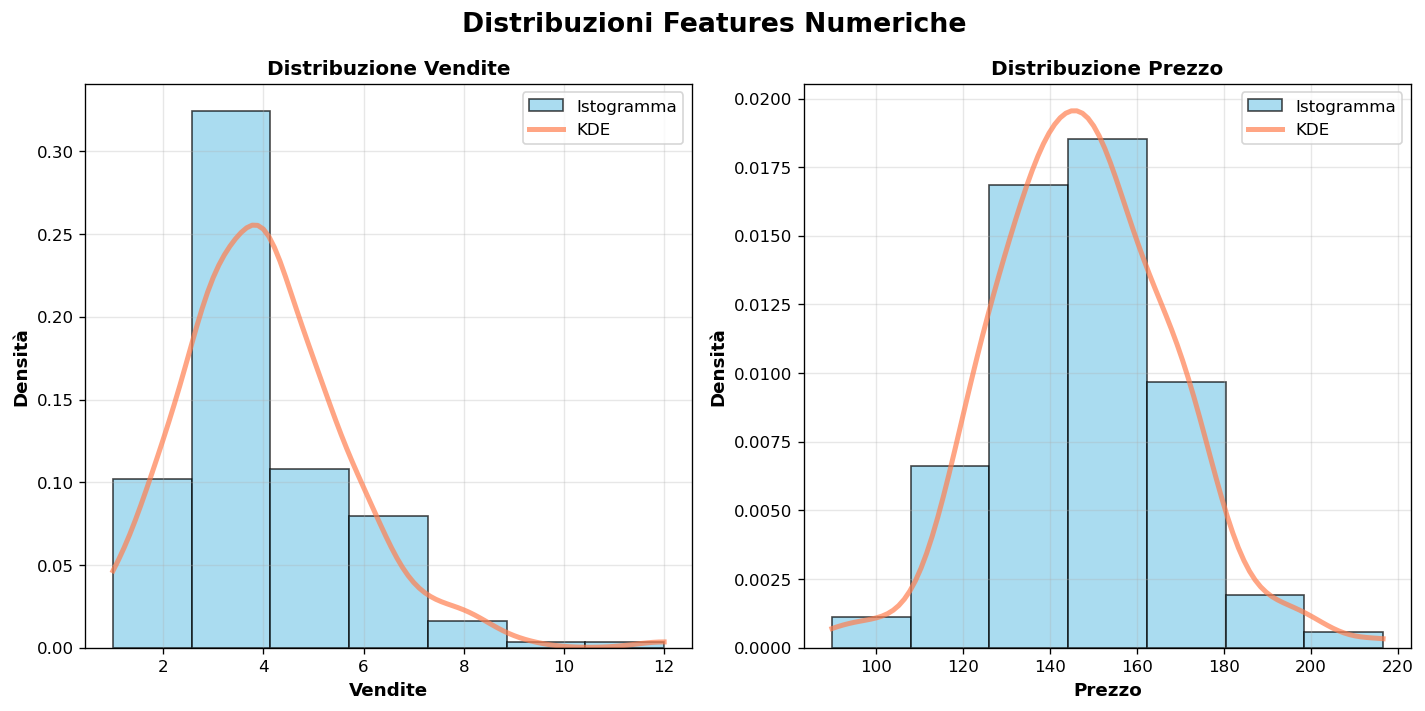

In [51]:
## 5. Plot distribuzioni features numeriche
print(f"{'>'*10} Grafico - Distribuzioni Features Numeriche")
fig, axes = plt.subplots(1, 2, figsize=(12,6), dpi=120)
fig.suptitle(f'Distribuzioni Features Numeriche', fontsize=16, fontweight='bold')

for idx, col in enumerate(df.columns[2:]):
    # Calcolo KDE
    kde = stats.gaussian_kde(df[col])
    x_range = np.linspace(df[col].min(), df[col].max(), 100)
    # Aggiungo istogramma
    axes[idx].hist(
        df[col], bins=7, density=True, 
        alpha=0.7, color='skyblue', edgecolor='black',
        label='Istogramma'
    )
    # Aggiungo KDE
    axes[idx].plot(
        x_range, kde(x_range),
        alpha=0.7, color='coral', linewidth=3,
        label='KDE'
    )
    # Styling   
    axes[idx].set_xlabel(col, fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('Densità', fontsize=11, fontweight='bold')
    axes[idx].set_title(f"Distribuzione {col}", fontsize=12, fontweight='bold')
    axes[idx].legend(loc='best')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Analisi Esplorativa
In questa sezione si procede ad analizzare il Dataset ricavando informazioni utili. L'analisi è strutturata come segue:

1. **Analisi Categorica**:
    - si analizza la feature categorica **Prodotto** ricavandone le performance, cioè si individua il prodotto più venduto e quello meno venduto.
1. **Analisi Temporale**:
    - si analizza la feature numerica **Vendite** per estrarne il trend settimanale e mensile.

## Analisi categorica: Vendite per Prodotto

### Raggruppamento dati per Prodotto:
1. Calcolo Vendite totali per **Prodotto** tramite il metodo **groupby()**.
2. Calcolo Vendite medie per **Prodotto** tramite il metodo **groupby()**. 
3. Normalizzazione **Vendite_totali** nell'intervallo $[0,\ 1]$ tramite il metodo **transform()**.
4. Visualizzazione dati raggruppati e trasformati. 

In [52]:
## 1/2. Raggruppo per prodotto e aggrego Vendite per calcolare somma e media
df_prodotto = df.groupby('Prodotto', observed=True).agg(
    Vendite_totali = ('Vendite', 'sum'),
    Vendite_medie = ('Vendite', 'mean')
).round(2)

In [53]:
## 3. Normalizzo vendite totali nell'intervallo [0, 1]  
df_prodotto['Vendite_norm'] = df_prodotto['Vendite_totali'].transform(
    lambda x: x/x.sum()
).round(3)

In [54]:
## 4. Stampo dati raggruppati
print(f"{'>'*10} Dati raggruppati per Prodotto")
print(f"{'-'*60}")
print(df_prodotto)
print(f"{'-'*60}")

>>>>>>>>>> Dati raggruppati per Prodotto
------------------------------------------------------------
          Vendite_totali  Vendite_medie  Vendite_norm
Prodotto                                             
A                    276           4.25         0.343
B                    246           3.84         0.306
C                    282           3.97         0.351
------------------------------------------------------------


### Performance Prodotti
1. Ricerca **Prodotto** più venduto tramite il metodo **idxmax()**.
2. Ricerca **Prodotto** meno venduto tramite il metodo **idxmin()**.
3. Visualizzazione risultati.
4. Grafico **Analisi Vendite per Prodotto**:
    - grafico a barre vendite totali per prodotto,
    - grafico a torta percentuali vendite per prodotto rispetto alle vendite totali.

In [55]:
## 1/2. Trovo Prodotto più e meno venduto
prodotto_max = df_prodotto['Vendite_totali'].idxmax()
prodotto_min = df_prodotto['Vendite_totali'].idxmin()

## 3. Stampo risultati
print(f"{'>'*10} Performance Prodotti")
print(f"{'-'*40}")
print("Prodotto più venduto:", prodotto_max)
print("Prodotto meno venduto:", prodotto_min)
print(f"{'-'*40}")

>>>>>>>>>> Performance Prodotti
----------------------------------------
Prodotto più venduto: C
Prodotto meno venduto: B
----------------------------------------


>>>>>>>>>> Grafico - Analisi Vendite per Prodotto


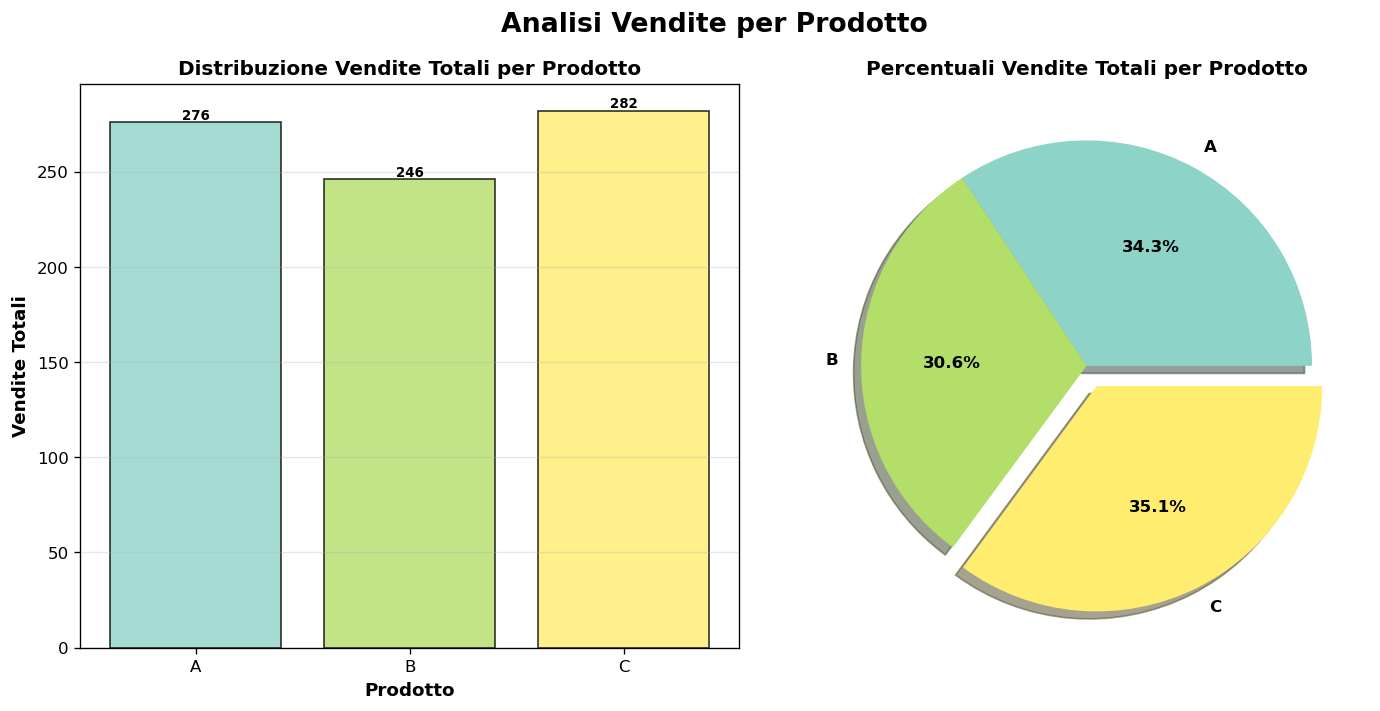

In [56]:
## 4. Grafico Vendite per Prodotto
print(f"{'>'*10} Grafico - Analisi Vendite per Prodotto")

fig, axes = plt.subplots(1, 2, figsize=(12,6), dpi=120)
fig.suptitle(f'Analisi Vendite per Prodotto', fontsize=16, fontweight='bold')

# Mappa colori per grafico a barre e grafico a torta
colors = plt.cm.Set3(np.linspace(0, 1, len(df_prodotto)))

# Aggiungo barre
bars = axes[0].bar(df_prodotto.index, df_prodotto['Vendite_totali'],
    color=colors, edgecolor='black', alpha=0.8)

# Aggiungo valore numerico sopra ogni barra
bar_value(axes[0], bars)

# Styling
axes[0].set_xlabel('Prodotto', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Vendite Totali', fontsize=11, fontweight='bold')
axes[0].set_title(f"Distribuzione Vendite Totali per Prodotto", fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

# Lista per evidenziare il prodotto più performante nel grafico a torta
explode = [0.1 if idx==prodotto_max else 0 for idx in df_prodotto.index]

# Aggiungo grafico a torta
axes[1].pie(
    df_prodotto['Vendite_norm'], 
    labels=df_prodotto.index, 
    autopct='%1.1f%%',
    colors=colors,
    shadow=True,
    explode = explode,
    textprops={'fontsize': 10, 'fontweight': 'bold'},
    pctdistance=0.6
)
axes[1].set_title(f"Percentuali Vendite Totali per Prodotto", fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## Analisi Temporale: Trend Vendite

### Trend Mensile
1. Aggiunta colonna **Mese** tramite il metodo **dt.to_period('M')**.
2. Raggruppamento dati per **Mese**.
3. Visualizzazione primi dati raggruppati

In [57]:
## 1. Aggiungo colonna 'Mese'
df['Mese'] = df['Data'].dt.to_period('M')

## 2. Raggruppo per Mese e aggrego Vendite per calcolare somma e media
df_mese = df.groupby('Mese').agg(
    Vendite_totali = ('Vendite', 'sum'),
    Vendite_media = ('Vendite', 'mean'),
    Mese_count = ('Data', 'count')  # calcolo il numero di giorni contenuti nel mese, utile per i grafici
).round(2)

## 3. Stampo primi dati mensili
print("Dati raggruppati per Mese")
print(f"{'-'*50}")
print(df_mese.head())
print(f"{'-'*50}")

Dati raggruppati per Mese
--------------------------------------------------
         Vendite_totali  Vendite_media  Mese_count
Mese                                              
2025-01             122           3.94          31
2025-02             117           4.18          28
2025-03             139           4.48          31
2025-04             118           3.93          30
2025-05             118           3.81          31
--------------------------------------------------


### Trend Settimanale
1. Aggiunta colonna **Settimana** tramite il metodo **dt.to_period('W')**.
2. Raggruppamento dati per **Settimana**.
3. Visualizzazione primi dati raggruppati

In [58]:
## 1. Aggiungo colonna 'Settimana'
df['Settimana'] = df['Data'].dt.to_period('W')

## 2. Raggruppo per Mese e aggrego Vendite per calcolare somma e media
df_settimana = df.groupby('Settimana').agg(
    Vendite_totali = ('Vendite', 'sum'),
    Vendite_media = ('Vendite', 'mean'),
    Settimana_count = ('Data', 'count'),  # calcolo il numero di giorni contenuti nel mese, utile per i grafici
    Settimana_first = ('Data', 'first')   # estraggo primo giorno della settimana, utile per i grafici
).round(2)

## 3. Stampo primi dati mensili
print("Dati raggruppati per Mese")
print(f"{'-'*70}")
print(df_settimana.head())
print(f"{'-'*70}")

Dati raggruppati per Mese
----------------------------------------------------------------------
                       Vendite_totali  Vendite_media  Settimana_count  \
Settimana                                                               
2024-12-30/2025-01-05              15           3.00                5   
2025-01-06/2025-01-12              28           4.00                7   
2025-01-13/2025-01-19              30           4.29                7   
2025-01-20/2025-01-26              29           4.14                7   
2025-01-27/2025-02-02              29           4.14                7   

                      Settimana_first  
Settimana                              
2024-12-30/2025-01-05      2025-01-01  
2025-01-06/2025-01-12      2025-01-06  
2025-01-13/2025-01-19      2025-01-13  
2025-01-20/2025-01-26      2025-01-20  
2025-01-27/2025-02-02      2025-01-27  
----------------------------------------------------------------------


>>>>>>>>>> Grafico - Trend Vendite


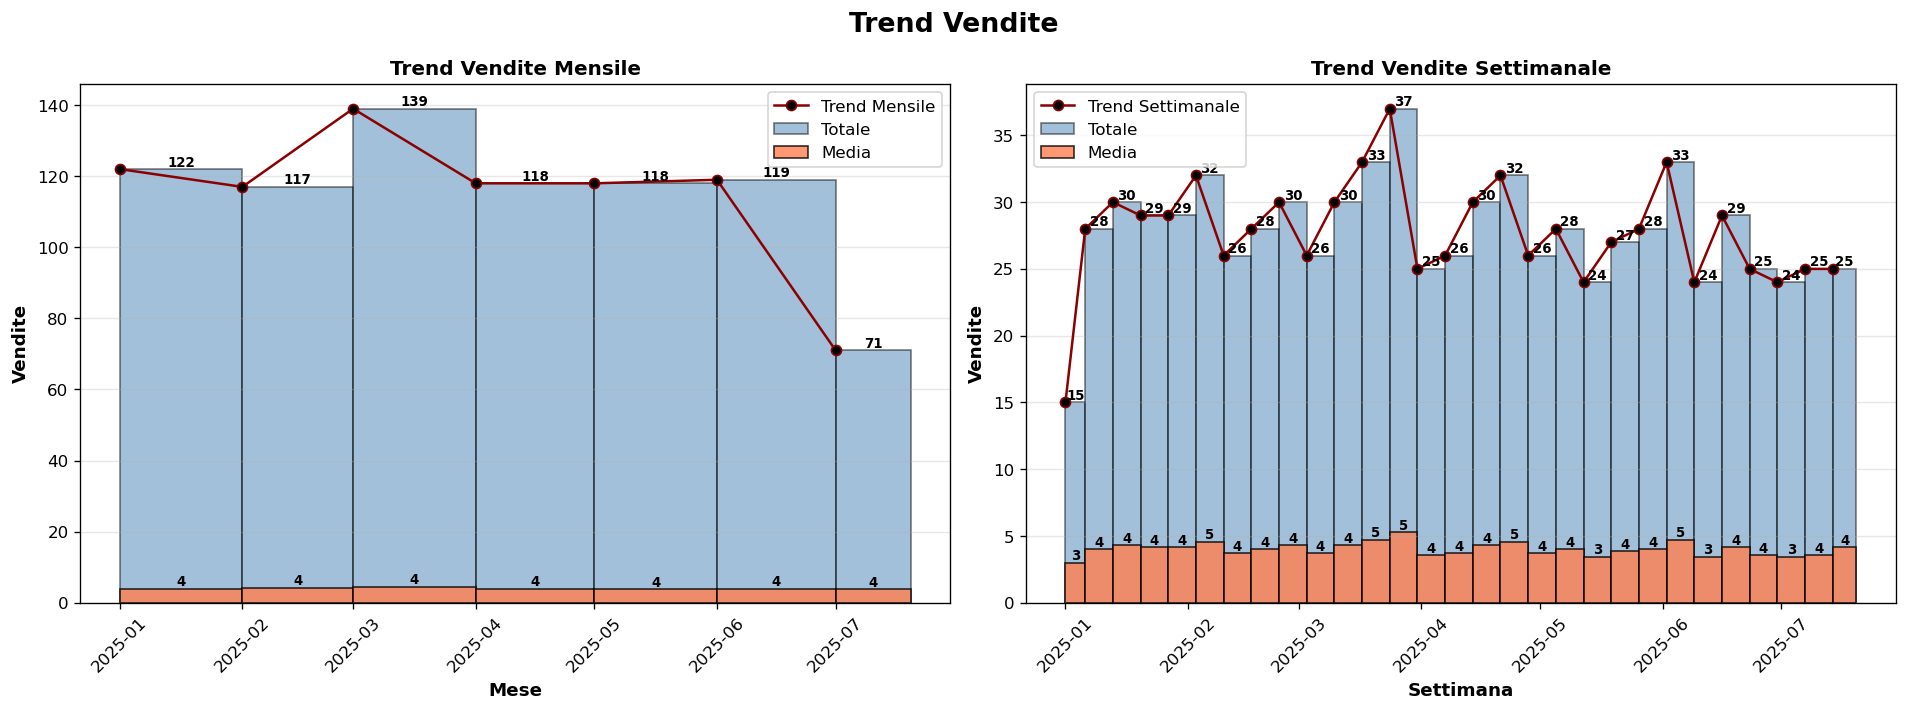

In [59]:
## Grafico Trend Vendite
print(f"{'>'*10} Grafico - Trend Vendite") 

fig, axes = plt.subplots(1, 2, figsize=(16,6), dpi=120)
fig.suptitle('Trend Vendite', fontsize=16, fontweight='bold')

##### Subplot Trend Mensile #####

# Converto indici in timestamp per asse x
indici = df_mese.index.to_timestamp()

# Aggiungo barre vendite totali
bars1 = axes[0].bar(
    indici, df_mese['Vendite_totali'], 
    color='steelblue', edgecolor='black', alpha=0.5,
    width=df_mese['Mese_count'], align='edge',
    label='Totale'
)
# Aggiungo barre vendite medie
bars2 = axes[0].bar(
    indici, df_mese['Vendite_media'], 
    color='coral', edgecolor='black', alpha=0.8,
    width=df_mese['Mese_count'], align='edge',
    label='Media'    
)
# Aggiungo valore numerico sopra ogni barra
bar_value(axes[0], bars1)
bar_value(axes[0], bars2)

# Aggiungo line per vendite totali
axes[0].plot(
    indici, df_mese['Vendite_totali'],
    color='darkred',
    marker='o', markerfacecolor='black',
    label='Trend Mensile'
)

# Styling
axes[0].set_title('Trend Vendite Mensile', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Mese', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Vendite', fontsize=11, fontweight='bold')
axes[0].tick_params(rotation=45, axis='x')
axes[0].legend(loc='best')
axes[0].grid(alpha=0.3, axis='y')

##### Subplot Trend Settimanale #####

# estraggo valori per asse x
indici = df_settimana['Settimana_first']

# Aggiungo barre vendite totali
bars1 = axes[1].bar(
    indici, df_settimana['Vendite_totali'], 
    color='steelblue', edgecolor='black', alpha=0.5,
    width=df_settimana['Settimana_count'], align='edge',
    label='Totale'
)
# Aggiungo barre vendite medie
bars2 = axes[1].bar(
    indici, df_settimana['Vendite_media'], 
    color='coral', edgecolor='black', alpha=0.8,
    width=df_settimana['Settimana_count'], align='edge', 
    label='Media'    
)
# Aggiungo valore numerico sopra ogni barra
bar_value(axes[1], bars1)
bar_value(axes[1], bars2)

# Aggiungo line per vendite totali
axes[1].plot(
    indici, df_settimana['Vendite_totali'],
    color='darkred',
    marker='o', markerfacecolor='black',
    label='Trend Settimanale'
)

# Styling
axes[1].set_title('Trend Vendite Settimanale', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Settimana', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Vendite', fontsize=11, fontweight='bold')
axes[1].tick_params(rotation=45, axis='x')
axes[1].legend(loc='best')
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Previsioni di Base e Confronti
In questa sezione si applicano varie strategie di previsione (**Media**, **Mediana**, **Ultimo Valore**). Il Dataset viene suddiviso in **Train** e **Test**. Le previsioni vengono calcolate con i dati del **Train** e poi vengono confrontate con i dati del **Test** per valutarne l'affidabilità. IL risultato finale viene poi riassunto in tabelle e nel grafico finale **Confronto Previsioni Vendite**. 

## Calcolo Previsioni
1. Suddivisione DataFrame in **Train** (**df_train**, 90%) e **Test** (**df_test**, 10%).
2. Metodi di Previsioni:
    - **Media**,
    - **Mediana**,
    - **Ultimo Valore**.
3. Salvataggio risultati di ogni strategia in un nuovo DataFrame **df_predict**:
    - **Vendite Previste** giornaliere (valore costante), 
    - **Vendite Totali Previste** nel periodo di riferimento, 
    - **Errore** calcolato come $Vendite \ Totali \ Previste \ - \ Vendite \ Totali \ Target$, dove **Vendite Totali Target** sono le vendite totali nel periodo di riferimento calcolate con i dati del **Test**.  
4. Grafici di confronto con dati di Test:
    - Trend **Vendite Previste** VS **Vendite** del Test,
    - Barre **Vendite Previste Totali** VS **Vendite Totali Target**.

In [ ]:
## 1. Divido il dataset in 90% train e 10% test

# Split DataFrame
split = int(len(df)*0.9) 

# Train
df_train = df.iloc[:split]

# Test
df_test = df.iloc[split:]

## 2. Calcolo Previsioni

# Metodo 1: media
media = df_train['Vendite'].mean()

# Metedo 2: mediana 
mediana = df_train['Vendite'].median()

# Metodo 3: ultimo valore
ultimo_valore = df_train["Vendite"].iloc[-1]

# Applicazione sui dati di test
previsioni = {
    'Media': media,
    'Mediana': mediana,
    'Ultimo Valore': ultimo_valore 
}

## 3. Creo DataFrame con risultati previsioni
df_predict = pd.DataFrame(previsioni.values(), index=previsioni.keys(), columns=['Vendite Previste'])

# Calcolo 'Vendite Totali Previste'
df_predict['Vendite Totali Previste'] = df_predict['Vendite Previste'] * len(df_test)

# Calcolo 'Errore'
df_predict['Errore'] = df_predict['Vendite Totali Previste'] - df_test['Vendite'].sum()

# Stampo previsioni
print(f"{'>'*10} Previsioni")
print(f"{'-'*70}")
print(df_predict.round(2))
print(f"{'-'*70}")

>>>>>>>>>> Previsioni
----------------------------------------------------------------------
               Vendite Previste  Vendite Totali Previste  Errore
Media                      4.06                    81.11    7.11
Mediana                    4.00                    80.00    6.00
Ultimo Valore              2.00                    40.00  -34.00
----------------------------------------------------------------------


>>>>>>>>>> Grafico - Confronto Previsioni Vendite


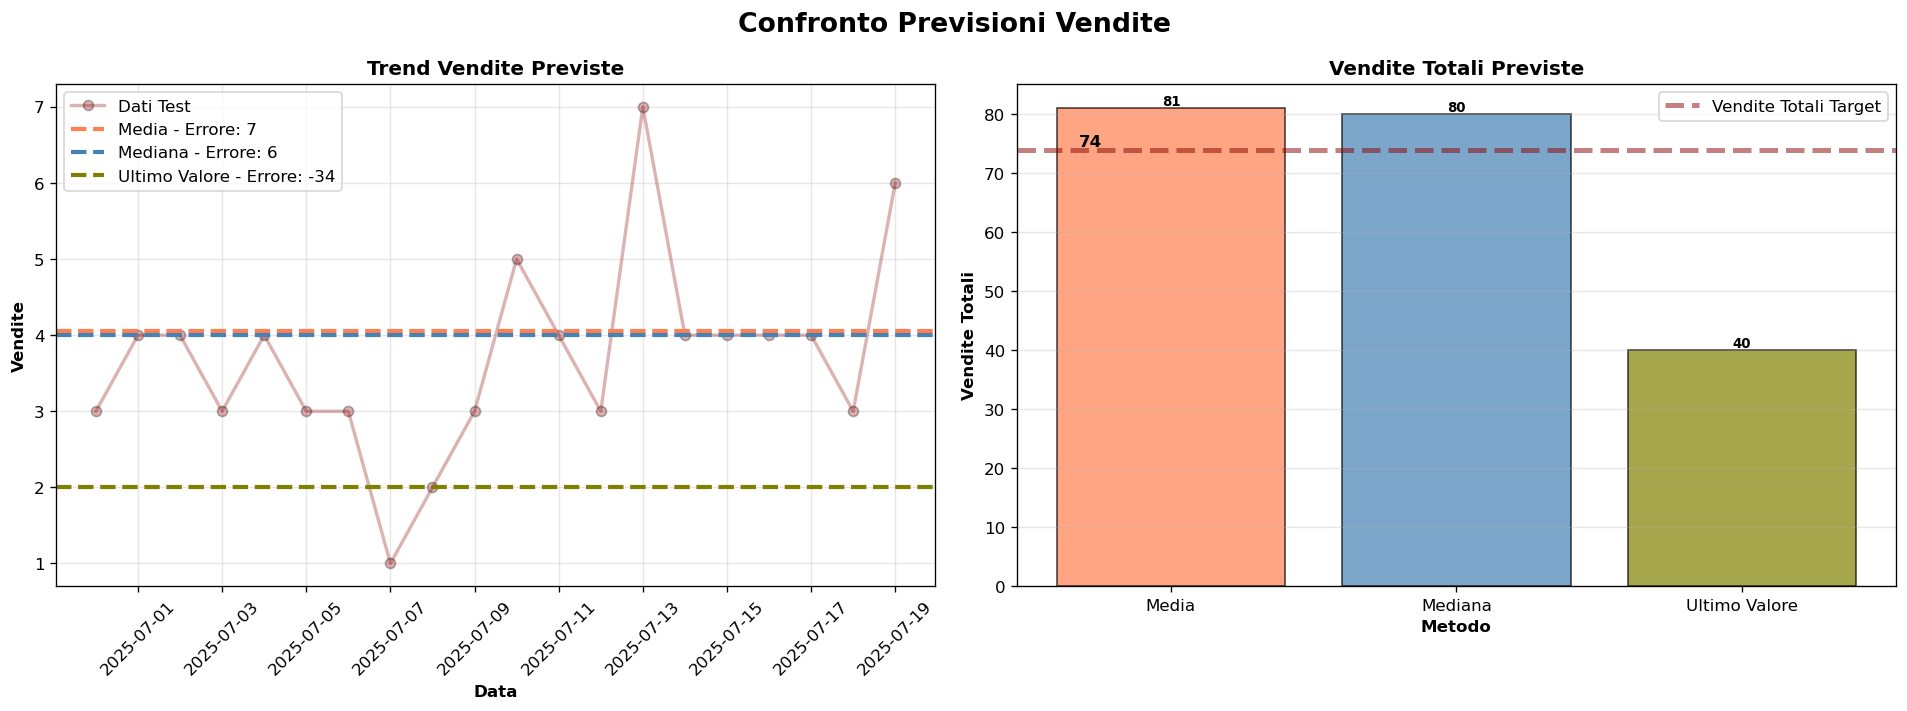

In [66]:
## 4. Grafici di confronto metodi di previsioni 
print(f"{'>'*10} Grafico - Confronto Previsioni Vendite")
fig, axes = plt.subplots(1, 2, figsize=(16,6), dpi=120)
fig.suptitle('Confronto Previsioni Vendite', fontsize=16, fontweight='bold')

# Plot dati test
axes[0].plot(
    df_test['Data'], df_test['Vendite'], 
    color='darkred', linewidth=2, alpha=0.3,
    marker='o', markeredgecolor='black',
    label='Dati Test'
)

# Mappa colori per i vari metodi
colors = ['coral', 'steelblue', 'olive']

# Plot hline per ogni metodo
for metodo, col in zip(df_predict.index, colors):
    axes[0].axhline(
        y=df_predict.loc[metodo]['Vendite Previste'],
        color=col, linestyle="--", linewidth=2.5,
        label=f"{metodo} - Errore: {df_predict.loc[metodo]['Errore']:.0f}"
    )
# Styling
axes[0].set_title('Trend Vendite Previste', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Data', fontsize=10, fontweight='bold')
axes[0].set_ylabel('Vendite', fontsize=10, fontweight='bold')
axes[0].tick_params(rotation=45, axis='x')
axes[0].legend(loc='best')
axes[0].grid(True, alpha=0.3)


# Plot bar vendite totali per ogni metodo
bars = axes[1].bar(
    df_predict.index, df_predict['Vendite Totali Previste'], 
    color=colors, edgecolor='black', alpha=0.7
)
# Aggiungo valore numerico su ogni barra
bar_value(axes[1], bars)

# Aggiungo valore target con hline, cioè le vendite totali del test
axes[1].axhline(
    y=df_test['Vendite'].sum(),
    color='darkred', linewidth=3, linestyle='--', alpha=0.5,
    label='Vendite Totali Target'
)
# Aggiungo valore numerico su hline target
axes[1].text(
    bars[0].get_x() + 0.15 * bars[0].get_width(), 
    df_test['Vendite'].sum(),
    f"{df_test['Vendite'].sum():.0f}",
    ha='center', va='bottom', 
    fontsize=10, fontweight='bold'
    )
# Styling
axes[1].set_title('Vendite Totali Previste', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Metodo', fontsize=10, fontweight='bold')
axes[1].set_ylabel('Vendite Totali', fontsize=10, fontweight='bold')
axes[1].legend(loc='best')
axes[1].grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Conclusioni

## Info Dataset
Il Dataset è formato da $200$ record giornalieri di vendite ognuno con $4$ features:

   - **Data**,
   - **Prodotto**, categorica,
   - **Vendite**, numerica, contiene valori mancanti,
   - **Prezzo**, numerica.

Occupa in memoria uno spazio di $14.6KB$.

È stata effettuata l'analisi della simmetria delle features numeriche dalle quali risulta:

   - **Vendite**: distribuzione asimmetrica destra (coda lunga a destra), 
   - **Prezzo**: distribuzione simmetrica.

Tali risultati sono in linea con la natura del Dataset:
   
   - **Vendite**: distribuzione di Poisson
   - **Prezzo**: distribuzione Normale 

## Pulizia Dataset
1. Considerata l'asimmetria della feature **Vendite**, ho deciso di riempire i dati mancanti con la **mediana** per non distorcere la distribuzione originale.
2. Le operazione di Downcasting hanno ridotto l'uso di memoria da $14.6KB$ a $4.1KB$, fattore di compressione $\sim 3.5$. 
3. Il Grafico **Distribuzioni Features Numeriche** mostra le distribuzioni delle features numeriche del Dataset pulito. Le forme delle distribuzioni, ancora una volta, riflettono la natura del Dataset:
   - **Vendite**: distribuzione di Poisson
   - **Prezzo**: distribuzione Normale

## Previsioni
Il Dataset è stato suddiviso in **Train** (90%, primi $180$ record) e **Test** (10%, ultimi $20$ record) per le consuete operazioni di convalida. Sono state applicate le seguenti strategie di previsione:

1. **Media** - assumo che le vendite future siano costanti e pari alla media delle vendite del **Train**.
2. **Mediana** - assumo che le vendite future siano costanti e pari alla mediana delle vendite del **Train**.
3. **Ultimo Valore** - assumo che le vendite future siano costanti e pari all'ultimo valore osservato in **Train**.

Per ogni strategia è stato calcolato:

1. **Vendite Previste**, vendite giornaliere previste.
2. **Vendite Totali Previste**, vendite totali del periodo di riferimento.
3. **Errore**, calcolato come

    $Vendite \ Totali \ Previste \ - \ Vendite \ Totali \ Target$

    dove **Vendite Totali Target** sono le vendite totali nel periodo di riferimento calcolate con i dati del **Test**. Fornisce una misura indicativa di quanto la previsione sta sbagliando nel periodo di riferimento considerato:

    - $Errore  >  0 \ \Longrightarrow Vendite \ Totali \ Previste  >  Vendite \ Totali \ Target \Longrightarrow sovrastima$ 
    - $Errore  <  0 \ \Longrightarrow Vendite \ Totali \ Previste  <  Vendite \ Totali \ Target \Longrightarrow sottostima$

Le previsioni ottenute sono state confrontate con i dati del **Test** e confermano ciò che ci si aspettava:

- Le strategie **Media** e **Mediana** forniscono delle buone previsioni (**Errore** basso) in quanto riescono a intercettare il comportamento medio delle **Vendite**. Bisogno però precisare che queste strategie non sono in grado di individuare tra i dati un trend che non sia costante! 
- La strategia **Ultimo Valore** è fortemente sensibile alla varianza della feature in esame. Nel nostro caso, la feature **Vendite** è soggetta ad alta varianza, di conseguenza tale strategia potrebbe fornire un range di valori troppo ampio per essere affidabile (ripetendo tale previsione più volte con dati diversi si ottengono stime molto diverse tra loro). Infatti nel nostro caso si ottiene una sottostima con **Errore** molto alto. 